<a href="https://colab.research.google.com/github/seobojung/ABCD-A/blob/20250515/yolo_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install ultralytics

  Using cached ultralytics-8.3.134-py3-none-any.whl.metadata (37 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached ultralytics-8.3.134-py3-none-any.whl (1.0 MB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)
  Attempting uninstall: nvidia-cusolver-cu12
    Found existing installation: nvidia-cusolver-cu12 11.6.3.83
    Uninstalling nvidia-cusolver-cu12-11.6.3.83:
      Successfully uninstalled nvidia-cusolver-cu12-11.6.3.83


In [17]:
from google.colab import files
uploaded = files.upload()

Saving yolo2.png to yolo2 (1).png


In [18]:
from ultralytics import YOLO

# YOLOv8 모델 로드 (작은 버전)
model = YOLO('yolov8x.pt')

# 예측 수행
results = model('yolo2.png')


image 1/1 /content/yolo2.png: 640x640 3 cats, 6 dogs, 4487.2ms
Speed: 4.0ms preprocess, 4487.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


In [19]:
# 클래스 ID → 이름 매핑 딕셔너리
names = model.names  # ex) {15: 'cat', 0: 'person', ...}

# 첫 번째 이미지 결과 객체
boxes = results[0].boxes

# 탐지된 클래스 ID 배열
class_ids = boxes.cls.cpu().numpy().astype(int)  # GPU 문제 방지

# 'cat'에 해당하는 ID 찾기
cat_id = [k for k, v in names.items() if v == 'cat'][0]

# 고양이 개수 세기
cat_count = (class_ids == cat_id).sum()
print(f"탐지된 고양이 마릿수: {cat_count}마리")

탐지된 고양이 마릿수: 3마리


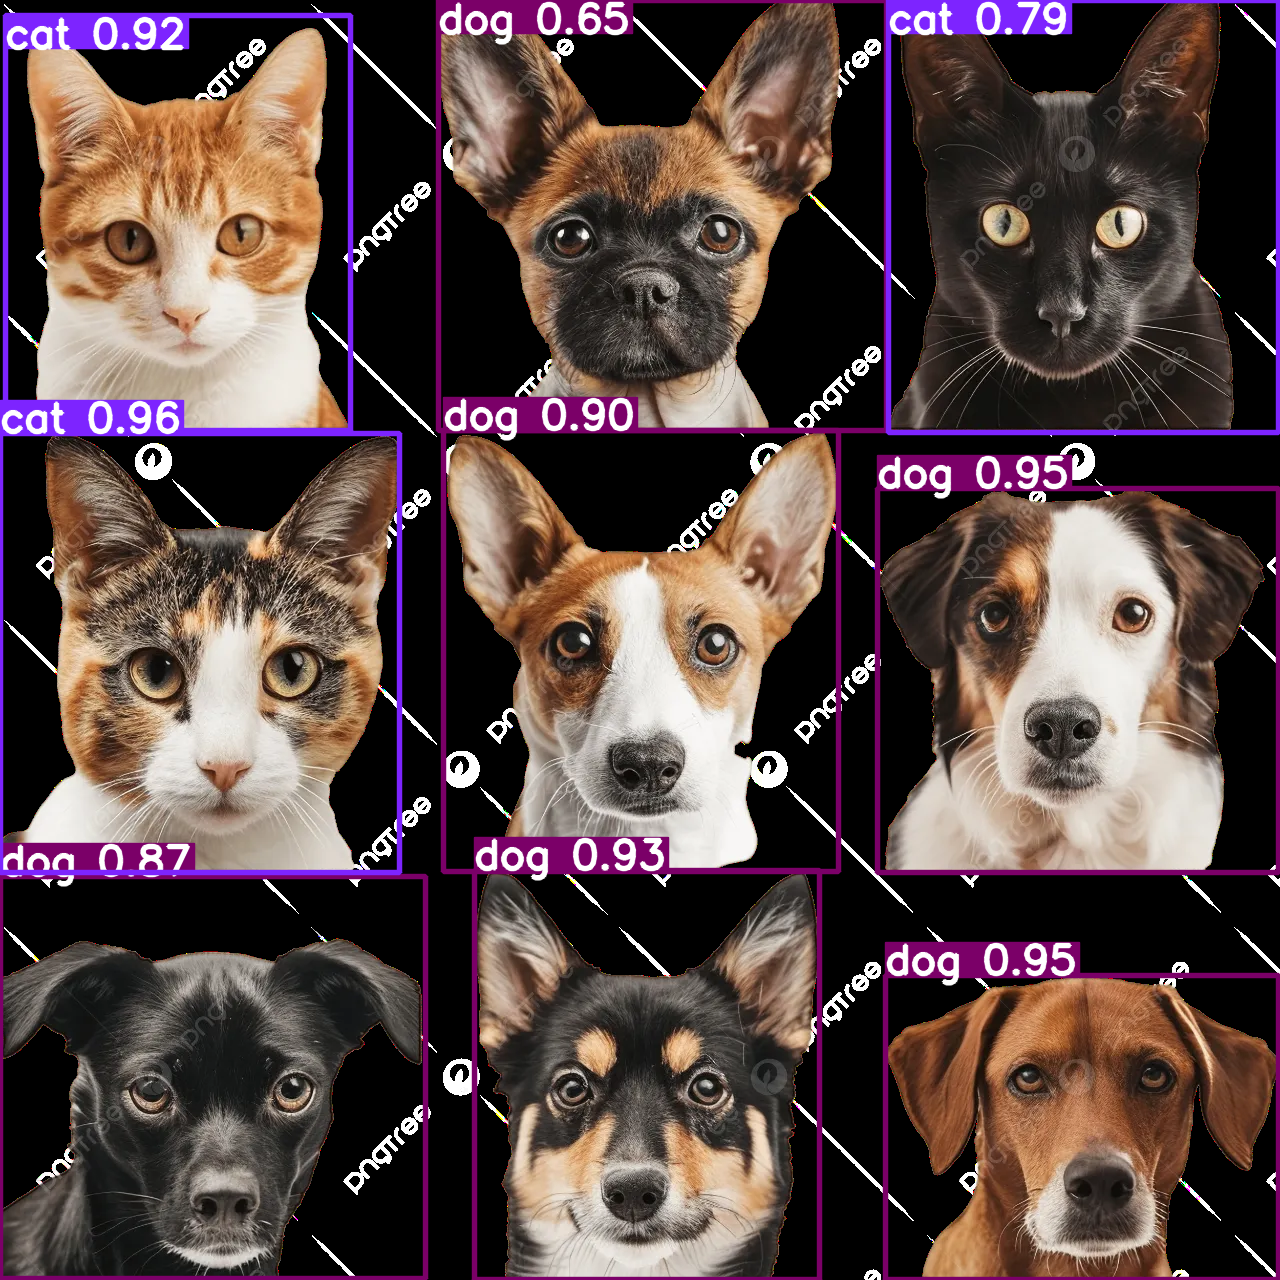

In [20]:
# 탐지 결과 시각화
results[0].show()